In [2]:
import numpy as np
import pandas as pd
import os
import librosa
import librosa.display
import IPython
from IPython.display import Audio
from IPython.display import Image
import matplotlib.pyplot as plt
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import random

In [8]:
EMOTIONS = {1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 0:'surprise'}


In [4]:

EMOTIONS = {1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 0:'surprise'}
DATA_PATH = '/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio'
SAMPLE_RATE = 48000

data_list = []
for dirname, _, filenames in os.walk(DATA_PATH):
    for filename in filenames:
        file_path = os.path.join('/kaggle/input/',dirname, filename)
        identifiers = filename.split('.')[0].split('-')
        emotion = (int(identifiers[2]))
        if emotion == 8:
            emotion = 0
        if int(identifiers[3]) == 1:
            emotion_intensity = 'normal' 
        else:
            emotion_intensity = 'strong'
        if int(identifiers[6])%2 == 0:
            gender = 'female'
        else:
            gender = 'male'
        
        data_list.append({"Emotion": emotion,
                            "Emotion intensity": emotion_intensity,
                            "Gender": gender,
                            "Path": file_path
                             })
        data = pd.DataFrame(data_list)

In [5]:
print("number of files is {}".format(len(data)))
data.head()

number of files is 2880


,Emotion,Emotion intensity,Gender,Path
0,0,normal,female,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
1,1,normal,female,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
2,7,strong,female,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
3,7,normal,female,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
4,1,normal,female,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...


Number of examples per emotion

Text(0, 0.5, 'Number of examples')

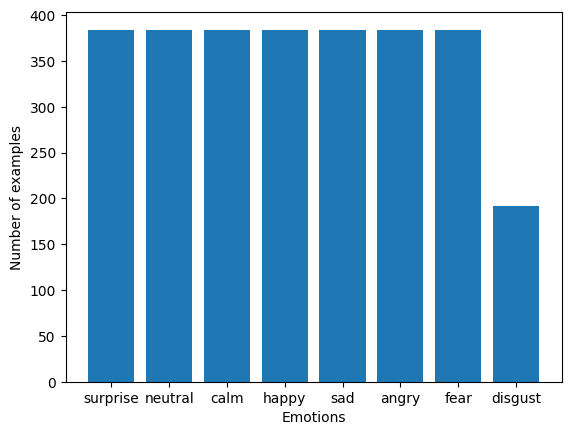

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.bar(x=range(8), height=data['Emotion'].value_counts())
ax.set_xticks(ticks=range(8))
ax.set_xticklabels([EMOTIONS[i] for i in range(8)],fontsize=10)
ax.set_xlabel('Emotions')
ax.set_ylabel('Number of examples')

number of examples per gender

Text(0, 0.5, 'Number of examples')

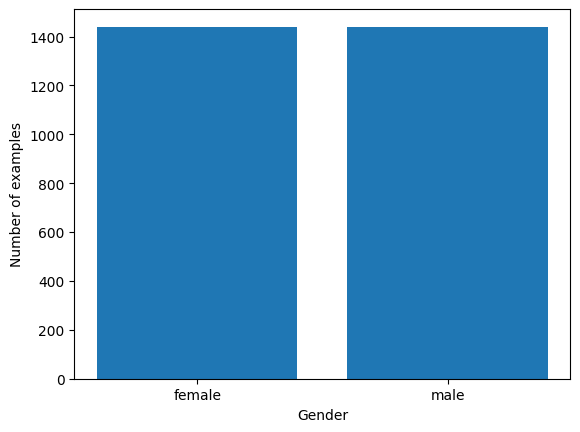

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111)
counts = data['Gender'].value_counts()
ax.bar(x=[0,1], height=counts.values)
ax.set_xticks(ticks=[0,1])
ax.set_xticklabels(list(counts.index))
ax.set_xlabel('Gender')
ax.set_ylabel('Number of examples')

number of examples per emotion intensity

Text(0, 0.5, 'Number of examples')

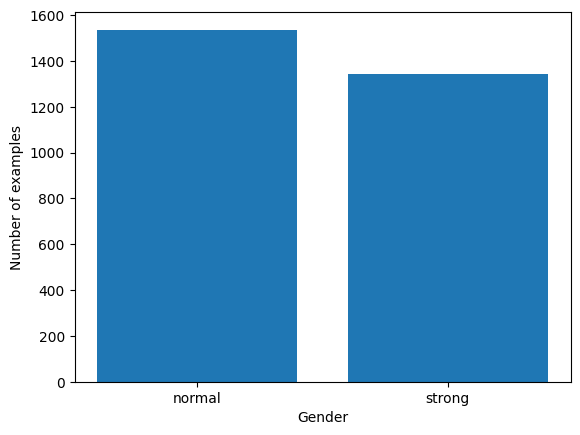

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)
counts = data['Emotion intensity'].value_counts()
ax.bar(x=[0,1], height=counts.values)
ax.set_xticks(ticks=[0,1])
ax.set_xticklabels(list(counts.index))
ax.set_xlabel('Gender')
ax.set_ylabel('Number of examples')

In [9]:
# 1. Dataset Class
class RAVDESSDataset(Dataset):
    def __init__(self, df, is_train=False, sample_rate=48000, duration=3):
        self.df = df
        self.is_train = is_train
        self.sr = sample_rate
        self.target_length = self.sr * duration

    def __len__(self):
        return len(self.df)
    
    def add_awgn(self, waveform, snr_low=15, snr_high=30):
        snr = random.uniform(snr_low, snr_high)
        signal_power = waveform.norm(p=2) ** 2 / waveform.numel()
        noise_power = signal_power / (10 ** (snr / 10))
        noise = torch.randn_like(waveform) * torch.sqrt(noise_power)
        return waveform + noise

    def __getitem__(self, idx):
        path = self.df.iloc[idx]['Path']
        label = self.df.iloc[idx]['Emotion']
        
        waveform, _ = torchaudio.load(path)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            
        if waveform.shape[1] > self.target_length:
            waveform = waveform[:, :self.target_length]
        elif waveform.shape[1] < self.target_length:
            padding = self.target_length - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, padding))
            
        if self.is_train and random.random() < 0.5:
            waveform = self.add_awgn(waveform)
            
        # Returning the RAW waveform now, not the Mel Spectrogram
        return waveform, torch.tensor(label, dtype=torch.long)
        
# 2. Replicate your original 80/10/10 per-emotion split cleanly
train_idx, val_idx, test_idx = [], [], []
for emotion in range(len(EMOTIONS)):
    indices = data[data.Emotion == emotion].index.tolist()
    np.random.shuffle(indices)
    m = len(indices)
    train_idx.extend(indices[:int(0.8*m)])
    val_idx.extend(indices[int(0.8*m):int(0.9*m)])
    test_idx.extend(indices[int(0.9*m):])

train_df = data.loc[train_idx].reset_index(drop=True)
val_df = data.loc[val_idx].reset_index(drop=True)
test_df = data.loc[test_idx].reset_index(drop=True)

# 3. Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(RAVDESSDataset(train_df, is_train=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(RAVDESSDataset(val_df, is_train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(RAVDESSDataset(test_df, is_train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 36 | Val batches: 5 | Test batches: 5


# Create the model

In [4]:
import torch
import torch.nn as nn

class ParallelModel(nn.Module):
    def __init__(self,num_emotions):
        super().__init__()
        # conv block
        self.conv2Dblock = nn.Sequential(
            # 1. conv block
            nn.Conv2d(in_channels=1,
                       out_channels=16,
                       kernel_size=3,
                       stride=1,
                       padding=1
                      ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(p=0.3),
            # 2. conv block
            nn.Conv2d(in_channels=16,
                       out_channels=32,
                       kernel_size=3,
                       stride=1,
                       padding=1
                      ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4, stride=4),
            nn.Dropout(p=0.3),
            # 3. conv block
            nn.Conv2d(in_channels=32,
                       out_channels=64,
                       kernel_size=3,
                       stride=1,
                       padding=1
                      ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4, stride=4),
            nn.Dropout(p=0.3),
            # 4. conv block
            nn.Conv2d(in_channels=64,
                       out_channels=64,
                       kernel_size=3,
                       stride=1,
                       padding=1
                      ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4, stride=4),
            nn.Dropout(p=0.3)
        )
        # Transformer block
        self.transf_maxpool = nn.MaxPool2d(kernel_size=[2,4], stride=[2,4])
        transf_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=512, dropout=0.4, activation='relu')
        self.transf_encoder = nn.TransformerEncoder(transf_layer, num_layers=4)
        # Linear softmax layer
        self.out_linear = nn.Linear(320,num_emotions)
        self.dropout_linear = nn.Dropout(p=0)
        self.out_softmax = nn.Softmax(dim=1)
    def forward(self,x):
        # conv embedding
        conv_embedding = self.conv2Dblock(x) #(b,channel,freq,time)
        conv_embedding = torch.flatten(conv_embedding, start_dim=1) # do not flatten batch dimension
        # transformer embedding
        x_reduced = self.transf_maxpool(x)
        x_reduced = torch.squeeze(x_reduced,1)
        x_reduced = x_reduced.permute(2,0,1) # requires shape = (time,batch,embedding)
        transf_out = self.transf_encoder(x_reduced)
        transf_embedding = torch.mean(transf_out, dim=0)
        # concatenate
        complete_embedding = torch.cat([conv_embedding, transf_embedding], dim=1) 
        # final Linear
        output_logits = self.out_linear(complete_embedding)
        output_logits = self.dropout_linear(output_logits)
        output_softmax = self.out_softmax(output_logits)
        return output_logits, output_softmax
                                     

In [11]:
def loss_fnc(predictions, targets):
    return nn.CrossEntropyLoss()(input=predictions,target=targets)

# TRAINING

In [12]:
EPOCHS = 800

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Selected device is {}'.format(device))

Selected device is cuda


In [14]:
model = ParallelModel(num_emotions=len(EMOTIONS)).to(device)
if torch.cuda.device_count() > 1:
    print(f"Distributing training across {torch.cuda.device_count()} gpus")
    model = nn.DataParallel(model)

model = model.to(device)
print('Number of trainable params: ',sum(p.numel() for p in model.parameters()) )
OPTIMIZER = torch.optim.SGD(model.parameters(),lr=0.01, weight_decay=1e-3, momentum=0.8)

/tmp/ipykernel_55/1730669493.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transf_encoder = nn.TransformerEncoder(transf_layer, num_layers=4)


Distributing training across 2 gpus
Number of trainable params:  395176


In [15]:
def load_checkpoint(model, optimizer, checkpoint_path, device):
    if not os.path.exists(checkpoint_path):
        print(f"No checkpoint found at '{checkpoint_path}'. Starting from scratch.")
        return 0, 0.0

    print(f"Checkpoint found! Loading from '{checkpoint_path}'...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Handle DataParallel prefix matching automatically
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint['model_state_dict'])
        
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    
    print(f"Resuming at Epoch {start_epoch} (Previous Best Acc: {best_val_acc:.2f}%)")
    return start_epoch, best_val_acc

In [16]:
# Initialize transforms on the GPU
mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=1024, win_length=512, 
    hop_length=256, n_mels=128, f_max=SAMPLE_RATE / 2.0
).to(device)

db_transform = T.AmplitudeToDB().to(device)

def process_mel_batch_gpu(waveforms):
    # 1. Compute Mel Spectrograms for the entire batch simultaneously
    mel_specs = db_transform(mel_transform(waveforms))
    
    # 2. Vectorized Per-Sample Normalization
    # Calculate mean and std across the frequency and time dimensions
    mean = mel_specs.mean(dim=(-1, -2), keepdim=True)
    std = mel_specs.std(dim=(-1, -2), keepdim=True)
    
    # Apply normalization, avoiding division by zero
    mel_specs = torch.where(std > 1e-6, (mel_specs - mean) / std, mel_specs - mean)
    
    return mel_specs

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


In [17]:
SAVE_PATH = os.path.join(os.getcwd(), 'models')
os.makedirs(SAVE_PATH, exist_ok=True)
BEST_MODEL_FILE = os.path.join(SAVE_PATH, 'cnn_transf_parallel_model_best.pt')
start_epoch, best_val_acc = load_checkpoint(model, OPTIMIZER, BEST_MODEL_FILE, device)

def validate(model, loader, loss_fnc, device):
    model.eval()
    total_loss, total_acc = 0, 0
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            
            # --- NEW: Convert to Mel Spec on GPU ---
            X_batch = process_mel_batch_gpu(X_batch)
            
            output_logits, output_softmax = model(X_batch)
            loss = loss_fnc(output_logits, Y_batch)
            preds = torch.argmax(output_softmax, dim=1)
            total_loss += loss.item() * len(Y_batch)
            total_acc += torch.sum(Y_batch == preds).item()
    return total_loss / len(loader.dataset), (total_acc / len(loader.dataset)) * 100

losses, val_losses = [], []

for epoch in range(start_epoch, EPOCHS):
    model.train()
    epoch_loss, epoch_acc = 0, 0
    
    for i, (X_batch, Y_batch) in enumerate(train_loader):
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        
        # --- NEW: Convert to Mel Spec on GPU ---
        X_batch = process_mel_batch_gpu(X_batch)
        
        # Forward
        output_logits, output_softmax = model(X_batch)
        loss = loss_fnc(output_logits, Y_batch)
        
        # Backward
        OPTIMIZER.zero_grad()
        loss.backward()
        OPTIMIZER.step()
        
        # Metrics
        preds = torch.argmax(output_softmax, dim=1)
        epoch_loss += loss.item() * len(Y_batch)
        epoch_acc += torch.sum(Y_batch == preds).item()
        
        print(f"\r Epoch {epoch}: iteration {i+1}/{len(train_loader)}", end='')
        
    epoch_loss /= len(train_loader.dataset)
    epoch_acc = (epoch_acc / len(train_loader.dataset)) * 100
    
    val_loss, val_acc = validate(model, val_loader, loss_fnc, device)
    
    losses.append(epoch_loss)
    val_losses.append(val_loss)
    
    print(f"\nEpoch {epoch} --> loss:{epoch_loss:.4f}, acc:{epoch_acc:.2f}%, val_loss:{val_loss:.4f}, val_acc:{val_acc:.2f}%")
    
    # ... (Keep checkpoint saving logic exactly the same) ...
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
            'optimizer_state_dict': OPTIMIZER.state_dict(),
            'best_val_acc': best_val_acc,
            'loss': val_loss
        }
        torch.save(checkpoint, BEST_MODEL_FILE)
        print(f"New best model checkpoint. (Accuracy: {best_val_acc:.2f}%)")

No checkpoint found at '/kaggle/working/models/cnn_transf_parallel_model_best.pt'. Starting from scratch.
 Epoch 0: iteration 36/36
Epoch 0 --> loss:2.3072, acc:15.12%, val_loss:2.0446, val_acc:17.89%
New best model checkpoint. (Accuracy: 17.89%)
 Epoch 1: iteration 36/36
Epoch 1 --> loss:1.9752, acc:22.68%, val_loss:1.9172, val_acc:27.02%
New best model checkpoint. (Accuracy: 27.02%)
 Epoch 2: iteration 36/36
Epoch 2 --> loss:1.8360, acc:28.45%, val_loss:1.9077, val_acc:28.42%
New best model checkpoint. (Accuracy: 28.42%)
 Epoch 3: iteration 36/36
Epoch 3 --> loss:1.7848, acc:31.36%, val_loss:1.6628, val_acc:36.49%
New best model checkpoint. (Accuracy: 36.49%)
 Epoch 4: iteration 36/36
Epoch 4 --> loss:1.6811, acc:36.53%, val_loss:1.6560, val_acc:37.89%
New best model checkpoint. (Accuracy: 37.89%)
 Epoch 5: iteration 36/36
Epoch 5 --> loss:1.6261, acc:37.36%, val_loss:1.7336, val_acc:28.07%
 Epoch 6: iteration 36/36
Epoch 6 --> loss:1.6302, acc:38.49%, val_loss:1.8936, val_acc:32.63%

KeyboardInterrupt: 

# Save model

In [18]:
SAVE_PATH = os.path.join(os.getcwd(),'models')
os.makedirs('models',exist_ok=True)

model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

torch.save(model_state, os.path.join(SAVE_PATH,'cnn_transf_parallel_model.pt'))
print('Model is saved to {}'.format(os.path.join(SAVE_PATH,'cnn_transf_parallel_model.pt')))

Model is saved to /kaggle/working/models/cnn_transf_parallel_model.pt


# Load model

In [11]:
model = ParallelModel(len(EMOTIONS))

# Update the path to point directly to your uploaded Kaggle dataset
MODEL_PATH = '/kaggle/input/models/varundamodaran/audio-model/pytorch/default/1/cnn_transf_parallel_model.pt'

# 1. Load the dictionary
state_dict = torch.load(MODEL_PATH, map_location=device)

# 2. Clean the dictionary keys (Removes the 'module.' prefix if saved via DataParallel)
state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

# 3. Load the cleaned weights into the model
model.load_state_dict(state_dict)

# 4. MOVE THE MODEL TO THE GPU
model = model.to(device)

print(f'Model is successfully loaded from {MODEL_PATH}')

/tmp/ipykernel_55/1730669493.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transf_encoder = nn.TransformerEncoder(transf_layer, num_layers=4)


Model is successfully loaded from /kaggle/input/models/varundamodaran/audio-model/pytorch/default/1/cnn_transf_parallel_model.pt


# Test

In [12]:
model.eval()
test_loss, test_acc = 0, 0
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        
        X_batch = process_mel_batch_gpu(X_batch)
        
        output_logits, output_softmax = model(X_batch)
        loss = loss_fnc(output_logits, Y_batch)
        preds = torch.argmax(output_softmax, dim=1)
        
        test_loss += loss.item() * len(Y_batch)
        test_acc += torch.sum(Y_batch == preds).item()
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(Y_batch.cpu().numpy())

test_loss /= len(test_loader.dataset)
test_acc = (test_acc / len(test_loader.dataset)) * 100

print(f'Test loss is {test_loss:.3f}')
print(f'Test accuracy is {test_acc:.2f}%')

# Re-assign variables for your correlation matrices further down the notebook
Y_test = np.array(all_targets)
predictions = np.array(all_preds)
test_ind = test_df.index.values # aligns with your dataframe correlation logic

NameError: name 'test_loader' is not defined

confusion matrix

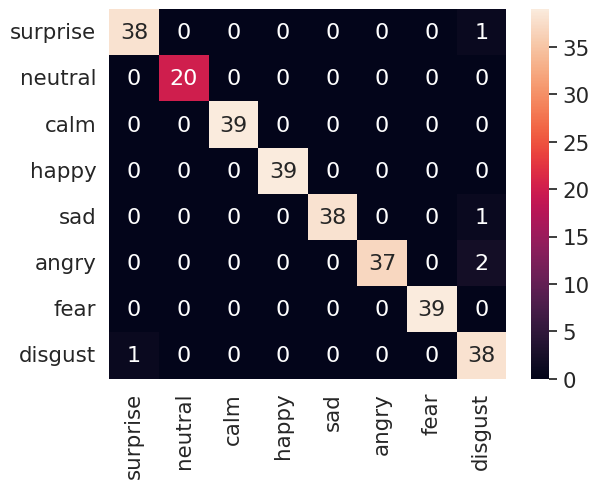

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sn

cm = confusion_matrix(Y_test, predictions)
names = [EMOTIONS[ind] for ind in range(len(EMOTIONS))]
df_cm = pd.DataFrame(cm, index=names, columns=names)

sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16})
plt.show()

correlation between emotion intensity and corectness

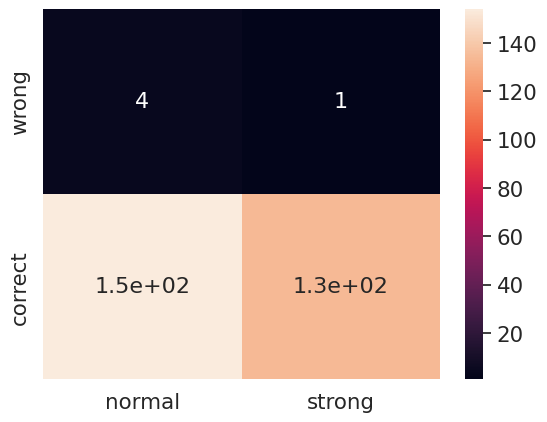

In [24]:
correct_strong = 0
correct_normal = 0
wrong_strong = 0
wrong_normal = 0

for i in range(len(test_df)):
    intensity = test_df.loc[i, 'Emotion intensity']
    if Y_test[i] == predictions[i]: # correct prediction
        if intensity == 'normal':
            correct_normal += 1
        else:
            correct_strong += 1
    else: # wrong prediction
        if intensity == 'normal':
            wrong_normal += 1
        else:
            wrong_strong += 1

array = np.array([[wrong_normal, wrong_strong], [correct_normal, correct_strong]])
df = pd.DataFrame(array, ['wrong', 'correct'], ['normal', 'strong'])
sn.set(font_scale=1.4)
sn.heatmap(df, annot=True, annot_kws={"size": 16})
plt.show()

correlation between gender and corectness

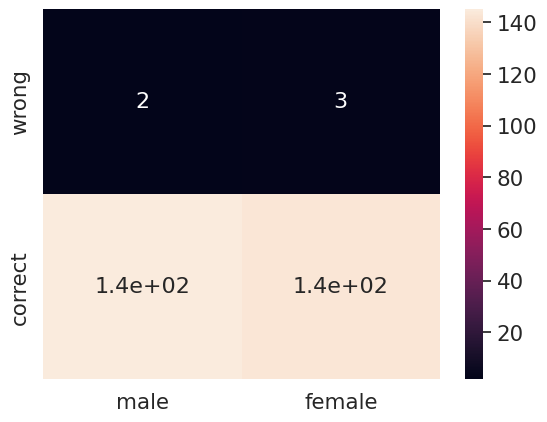

In [25]:
correct_male = 0
correct_female = 0
wrong_male = 0
wrong_female = 0

for i in range(len(test_df)):
    gender = test_df.loc[i, 'Gender']
    if Y_test[i] == predictions[i]: # correct prediction
        if gender == 'male':
            correct_male += 1
        else:
            correct_female += 1
    else: # wrong prediction
        if gender == 'male':
            wrong_male += 1
        else:
            wrong_female += 1

array = np.array([[wrong_male, wrong_female], [correct_male, correct_female]])
df = pd.DataFrame(array, ['wrong', 'correct'], ['male', 'female'])
sn.set(font_scale=1.4) 
sn.heatmap(df, annot=True, annot_kws={"size": 16}) 
plt.show()

# Plot loss

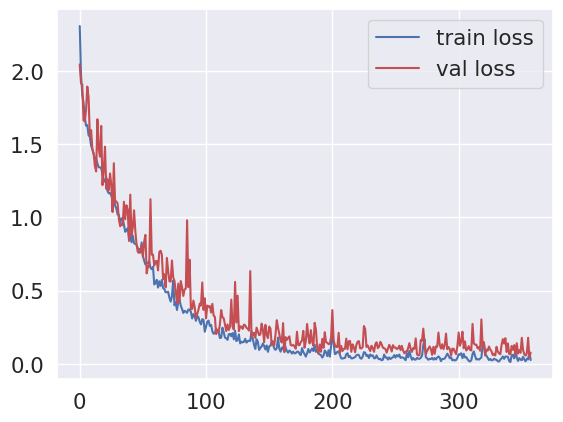

In [26]:
plt.plot(losses,'b')
plt.plot(val_losses,'r')
plt.legend(['train loss','val loss'])

In [13]:
import torch
import torchaudio
import torchaudio.transforms as T
import os

# 1. Define the exact parameters used during training
EMOTIONS = {1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 0:'surprise'}
SAMPLE_RATE = 48000
DURATION = 3
TARGET_LENGTH = SAMPLE_RATE * DURATION

def preprocess_audio(file_path):
    """Loads and formats a single audio file for the model."""
    # Load audio
    waveform, sr = torchaudio.load(file_path)
    
    # Resample if the incoming audio isn't 48kHz (crucial for real-world audio)
    if sr != SAMPLE_RATE:
        resampler = T.Resample(sr, SAMPLE_RATE)
        waveform = resampler(waveform)
        
    # Convert stereo to mono
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
        
    # Pad or trim to exactly 3 seconds
    if waveform.shape[1] > TARGET_LENGTH:
        waveform = waveform[:, :TARGET_LENGTH]
    elif waveform.shape[1] < TARGET_LENGTH:
        padding = TARGET_LENGTH - waveform.shape[1]
        waveform = torch.nn.functional.pad(waveform, (0, padding))
        
    # Apply Mel Spectrogram transform
    mel_transform = T.MelSpectrogram(
        sample_rate=SAMPLE_RATE, n_fft=1024, win_length=512, 
        hop_length=256, n_mels=128, f_max=SAMPLE_RATE / 2.0
    )
    db_transform = T.AmplitudeToDB()
    
    mel_spec = db_transform(mel_transform(waveform))
    
    # Normalize per sample
    mean = mel_spec.mean()
    std = mel_spec.std()
    mel_spec = (mel_spec - mean) / std if std > 1e-6 else mel_spec - mean
    
    # Add a batch dimension! The model expects (batch_size, channels, height, width)
    # Right now it is (channels, height, width), so we use unsqueeze(0)
    mel_spec = mel_spec.unsqueeze(0)
    
    return mel_spec

def predict_emotion(audio_path, model, device):
    """Runs the preprocessed audio through the model and returns the emotion."""
    model.eval() # Ensure model is in evaluation mode
    
    with torch.no_grad():
        # 1. Preprocess the raw audio
        input_tensor = preprocess_audio(audio_path).to(device)
        
        # 2. Pass through the model
        output_logits, output_softmax = model(input_tensor)
        
        # 3. Get the prediction
        pred_idx = torch.argmax(output_softmax, dim=1).item()
        
        # 4. Map back to the string label
        emotion_label = EMOTIONS[pred_idx]
        
        # Optional: Get the confidence percentage
        confidence = output_softmax[0][pred_idx].item() * 100
        
        return pred_idx, emotion_label, confidence

In [16]:
# Make sure your model is loaded and on the correct device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Provide the path to a test audio file (you can grab one from your test_df)
sample_audio_path = '/kaggle/input/datasets/varundamodaran/audio-test/Recording (4).m4a'
actual_emotion = 'angry'

# Run the pipeline
predicted_num, predicted_emotion, confidence = predict_emotion(sample_audio_path, model, device)

print(f"File: {sample_audio_path.split('/')[-1]}")
print(f"Actual Emotion: {actual_emotion}")
print("-" * 30)
print(f"Predicted Number: {predicted_num}")
print(f"Predicted Emotion: {predicted_emotion}")
print(f"Confidence: {confidence:.2f}%")

File: Recording (4).m4a
Actual Emotion: angry
------------------------------
Predicted Number: 2
Predicted Emotion: calm
Confidence: 99.99%
